In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("loan_eligibility_dataset.xlsx")

In [3]:
df

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area,Loan_Status
0,L001,Male,Yes,0,Graduate,No,50000,20000,200000,1,Urban,Y
1,L002,Female,No,0,Graduate,No,35000,0,150000,1,Urban,Y
2,L003,Male,Yes,1,Graduate,Yes,30000,10000,180000,0,Rural,N
3,L004,Male,No,0,Not Graduate,No,25000,5000,100000,1,Semiurban,Y
4,L005,Female,Yes,2,Graduate,No,45000,15000,250000,1,Urban,Y
5,L006,Male,Yes,3+,Not Graduate,Yes,28000,8000,200000,0,Rural,N
6,L007,Female,No,0,Graduate,No,60000,0,300000,1,Urban,Y
7,L008,Male,Yes,1,Graduate,No,32000,12000,150000,0,Rural,N
8,L009,Male,No,0,Graduate,No,55000,5000,180000,1,Semiurban,Y
9,L010,Female,Yes,2,Not Graduate,No,27000,10000,120000,0,Rural,N


In [4]:
df["Dependents"] = df["Dependents"].replace("3+", "3")
df

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area,Loan_Status
0,L001,Male,Yes,0,Graduate,No,50000,20000,200000,1,Urban,Y
1,L002,Female,No,0,Graduate,No,35000,0,150000,1,Urban,Y
2,L003,Male,Yes,1,Graduate,Yes,30000,10000,180000,0,Rural,N
3,L004,Male,No,0,Not Graduate,No,25000,5000,100000,1,Semiurban,Y
4,L005,Female,Yes,2,Graduate,No,45000,15000,250000,1,Urban,Y
5,L006,Male,Yes,3,Not Graduate,Yes,28000,8000,200000,0,Rural,N
6,L007,Female,No,0,Graduate,No,60000,0,300000,1,Urban,Y
7,L008,Male,Yes,1,Graduate,No,32000,12000,150000,0,Rural,N
8,L009,Male,No,0,Graduate,No,55000,5000,180000,1,Semiurban,Y
9,L010,Female,Yes,2,Not Graduate,No,27000,10000,120000,0,Rural,N


In [5]:

df.drop("Applicant_ID", axis=1)


for column in df.columns:

    if df[column].dtype in ["object", "string"]:
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())


encoders = {}


for column in df.select_dtypes(include=['string','object']).columns:
    lb = LabelEncoder()
    df[column] = lb.fit_transform(df[column])
    encoders[column] = lb
df

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area,Loan_Status
0,0,1,1,0,0,0,50000,20000,200000,1,2,1
1,1,0,0,0,0,0,35000,0,150000,1,2,1
2,2,1,1,1,0,1,30000,10000,180000,0,0,0
3,3,1,0,0,1,0,25000,5000,100000,1,1,1
4,4,0,1,2,0,0,45000,15000,250000,1,2,1
5,5,1,1,3,1,1,28000,8000,200000,0,0,0
6,6,0,0,0,0,0,60000,0,300000,1,2,1
7,7,1,1,1,0,0,32000,12000,150000,0,0,0
8,8,1,0,0,0,0,55000,5000,180000,1,1,1
9,9,0,1,2,1,0,27000,10000,120000,0,0,0


In [6]:
x = df.drop(["Applicant_ID", "Loan_Status"], axis=1)
x

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area
0,1,1,0,0,0,50000,20000,200000,1,2
1,0,0,0,0,0,35000,0,150000,1,2
2,1,1,1,0,1,30000,10000,180000,0,0
3,1,0,0,1,0,25000,5000,100000,1,1
4,0,1,2,0,0,45000,15000,250000,1,2
5,1,1,3,1,1,28000,8000,200000,0,0
6,0,0,0,0,0,60000,0,300000,1,2
7,1,1,1,0,0,32000,12000,150000,0,0
8,1,0,0,0,0,55000,5000,180000,1,1
9,0,1,2,1,0,27000,10000,120000,0,0


In [7]:
y = df[["Loan_Status"]]
y

,Loan_Status
0,1
1,1
2,0
3,1
4,1
5,0
6,1
7,0
8,1
9,0


In [8]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
model = RandomForestClassifier(criterion='entropy', max_depth=3)
model.fit(xtrain, ytrain)

c:\Python314\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
ypred = model.predict(xtest)
ypred

array([1, 0, 1, 1])

In [11]:
print("Accuracy : ", accuracy_score(ytest, ypred)*100)

Accuracy :  100.0


In [12]:
model = RandomForestClassifier(criterion='entropy', max_depth=3)
model.fit(xtrain, ytrain)

c:\Python314\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
ypred = model.predict(xtest)
ypred

array([1, 0, 1, 1])

In [14]:
print("Accuracy : ", accuracy_score(ytest, ypred)*100)

Accuracy :  100.0


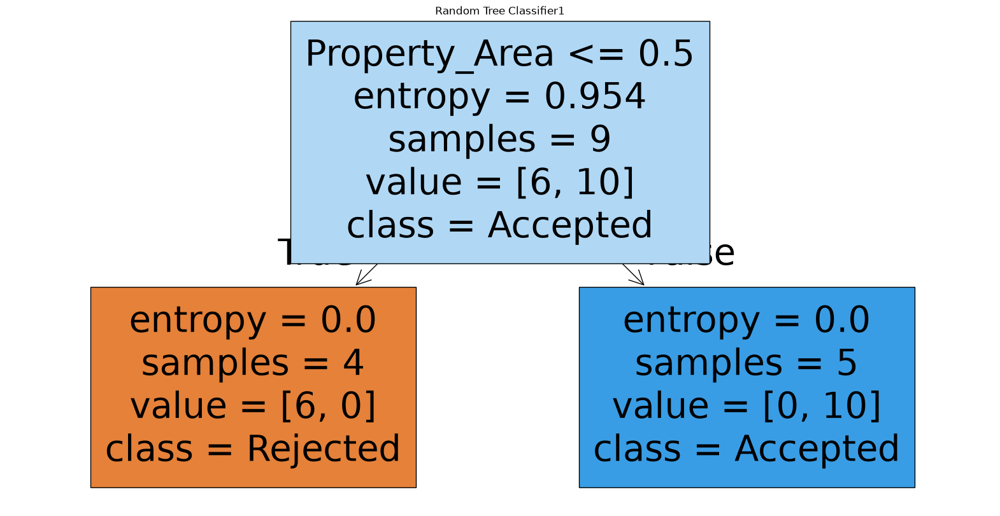

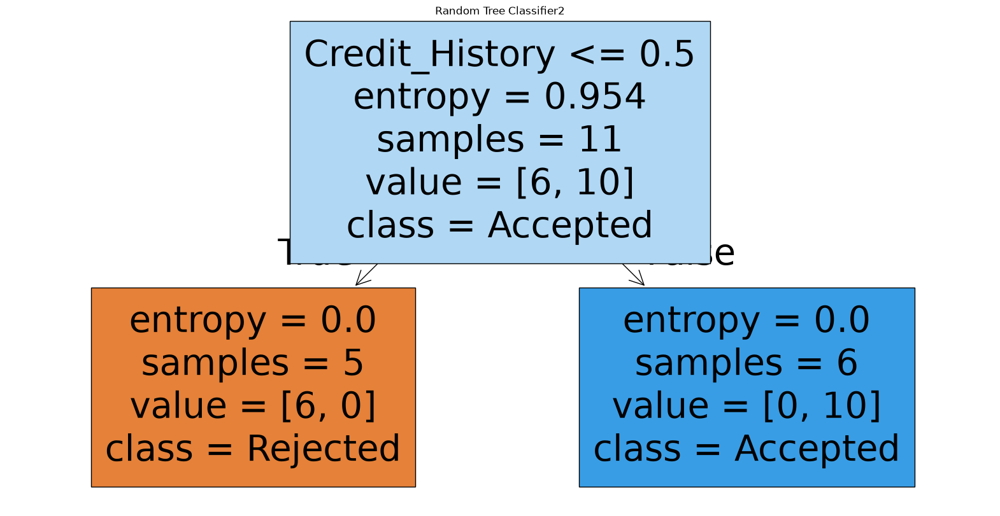

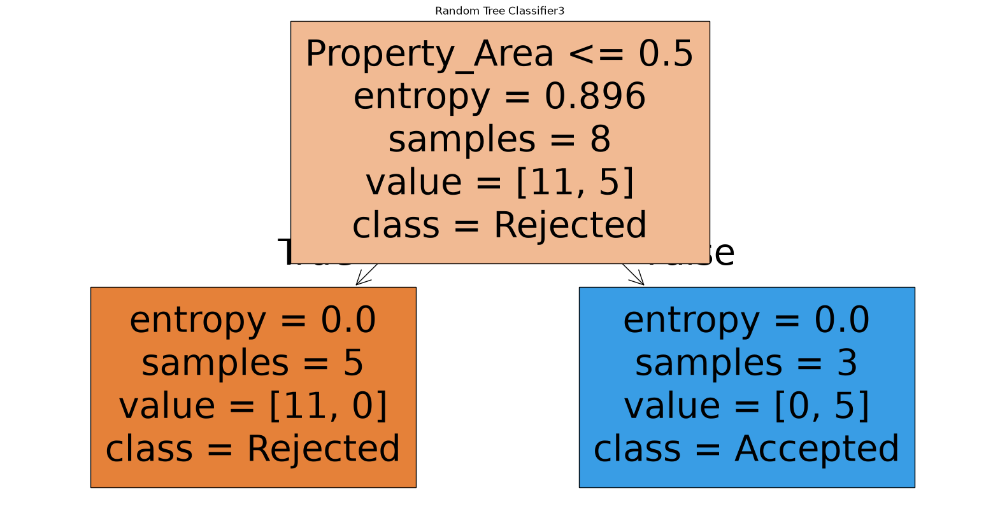

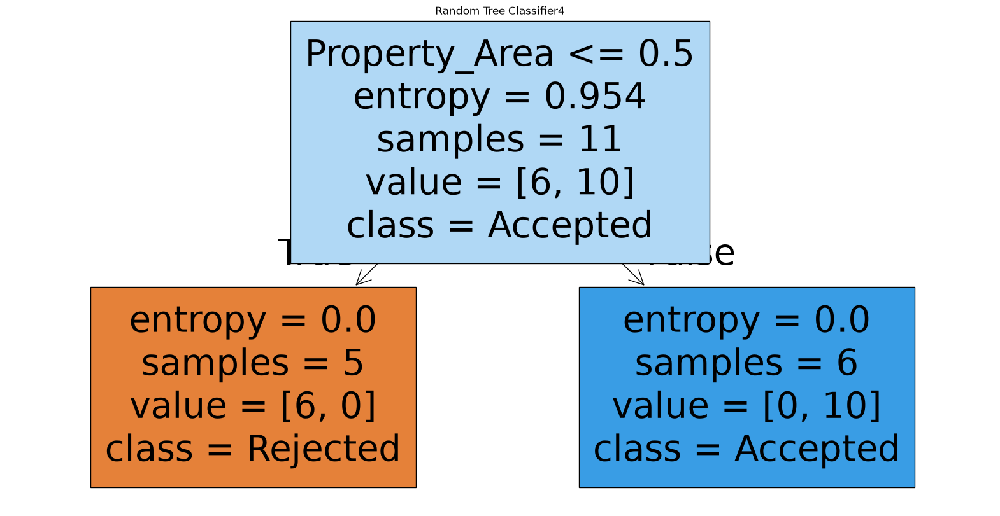

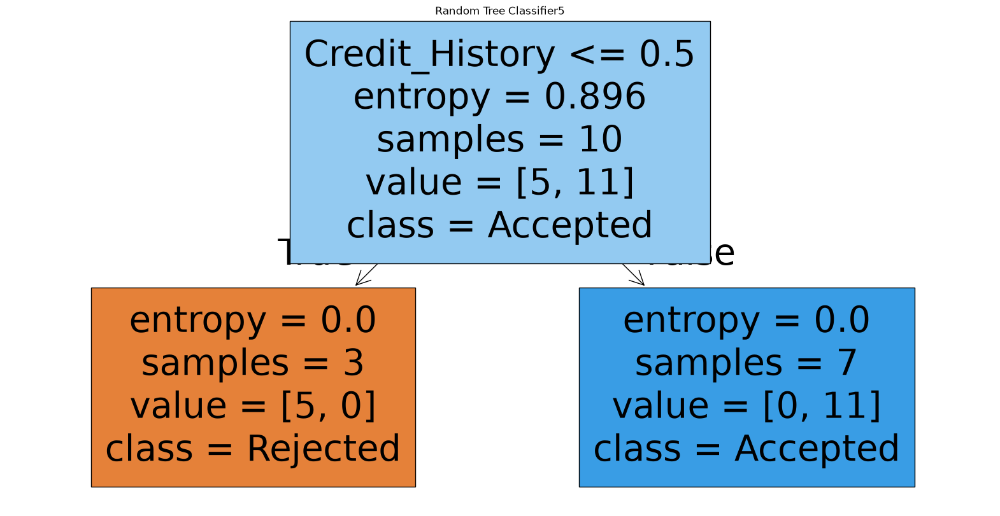

...

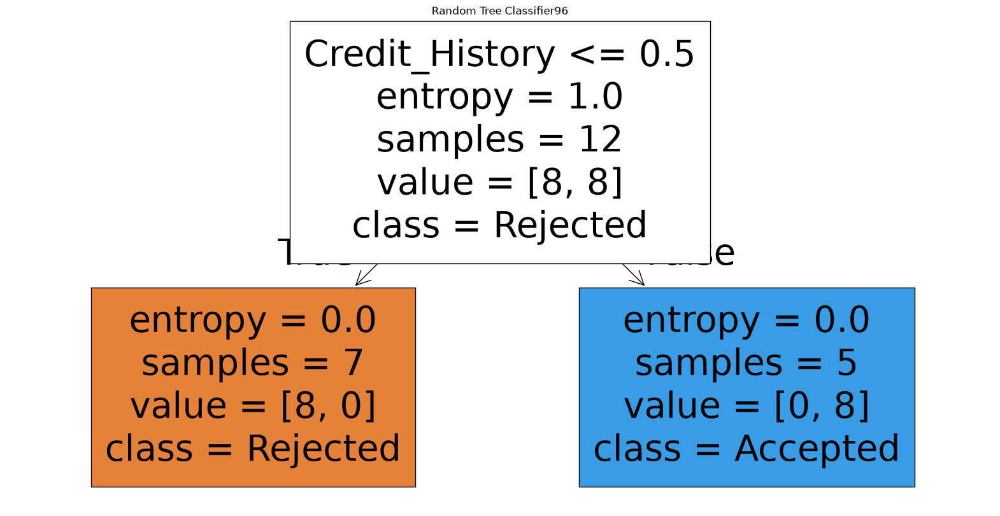

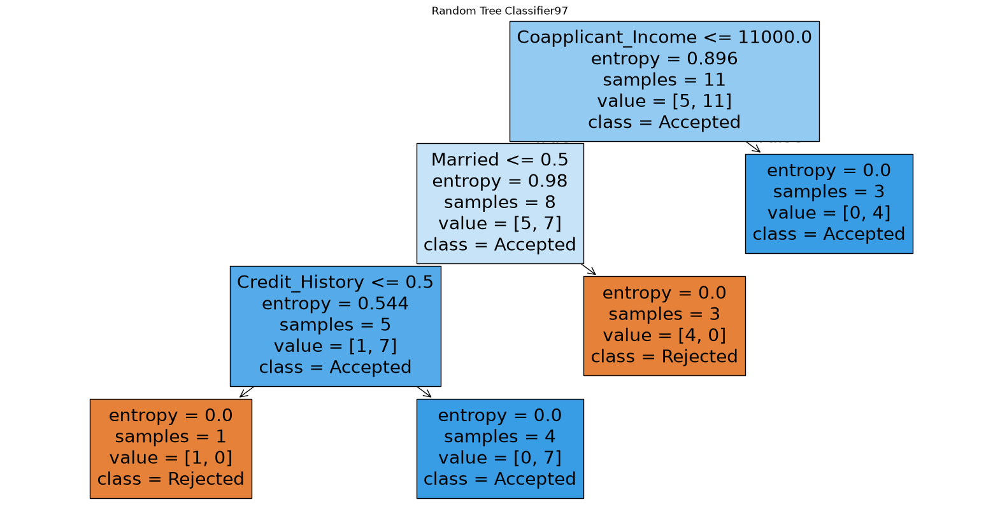

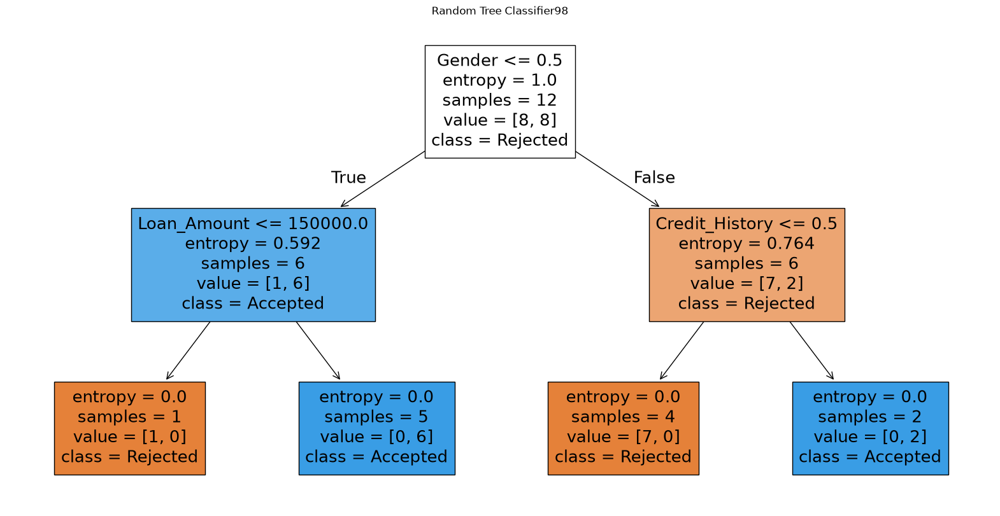

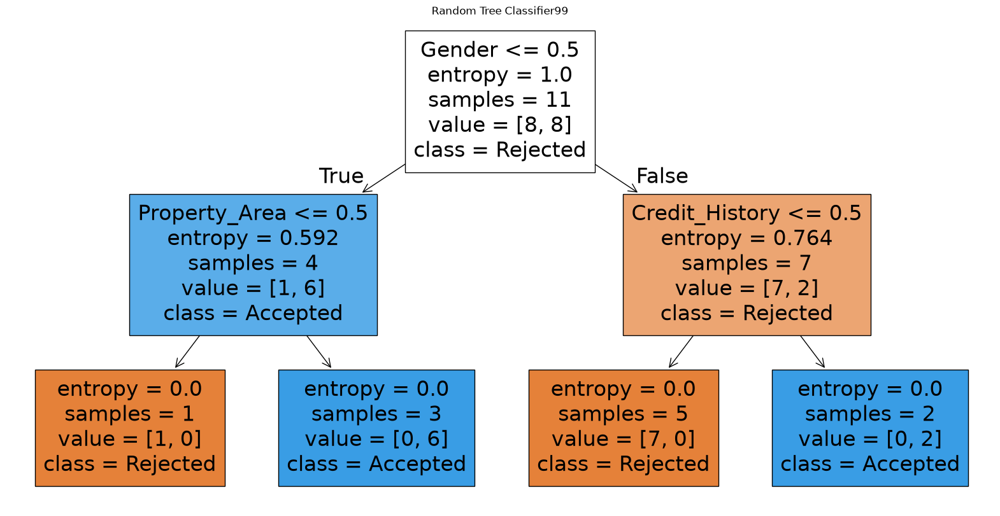

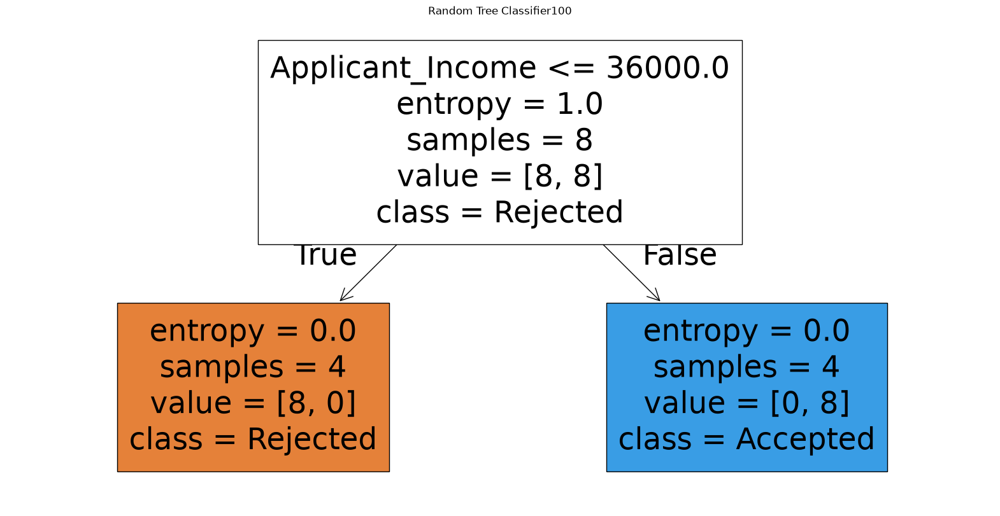

In [15]:
for i, tree in enumerate(model.estimators_):

    plt.figure(figsize=(20, 10))

    plot_tree(tree, feature_names=x.columns, class_names=["Rejected", "Accepted"], filled=True)

    plt.title(f"Random Tree Classifier{i+1}")

    plt.show()

In [16]:
new_user = pd.DataFrame([{
    "Gender":"Male",
    "Married":"Yes",
    "Dependents":"0",
    "Education":"Graduate",
    "Self_Employed":"No",
    "Applicant_Income":5000,
    "Coapplicant_Income":1500,
    "Loan_Amount":8000000,
    "Credit_History":1,
    "Property_Area":"Urban"

}])
print(x.columns.tolist())
print(new_user.columns.tolist())

for column, encoder in encoders.items():
    if column in new_user.columns:
        new_user[column]=encoder.transform(new_user[column].astype(str))

new_user = new_user[x.columns]

prediction = model.predict(new_user)

loan_status = encoders["Loan_Status"].inverse_transform(prediction)

print("loan_eligibility:", loan_status[0])

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Credit_History', 'Property_Area']
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Credit_History', 'Property_Area']
loan_eligibility: Y
